In [36]:
import numpy as np
from pymoo.core.problem import Problem

class Schaffer(Problem):

    def __init__(self):
        super().__init__(
            n_var=1,
            n_obj=2,
            n_constr=0,
            xl=-5,
            xu=5
        )

    def _evaluate(self, x, out, *args, **kwargs):
        f1 = x[:, 0] ** 2
        f2 = (x[:, 0] - 2) ** 2
        out["F"] = np.column_stack([f1, f2])

In [37]:
from pymoo.algorithms.moo.nsga2 import NSGA2


problem = Schaffer()

from pymoo.optimize import minimize

res = minimize(
    problem,
    NSGA2(pop_size=100),
    termination=("n_gen", 100)
)

# -------------------
# PRINT RESULTS
# -------------------

print("Best solutions (X):")
print(res.X)

print("\nObjective values (F):")
print(res.F)

Best solutions (X):
[[3.90215451e-05]
 [1.99992654e+00]
 [1.16860647e+00]
 [6.49426037e-01]
 [1.11532771e+00]
 [9.03608869e-01]
 [1.50896126e+00]
 [1.54427095e+00]
 [1.66397636e-01]
 [1.57480562e+00]
 [1.86788484e+00]
 [2.13891449e-01]
 [6.89652405e-01]
 [9.91681878e-01]
 [1.26423324e+00]
 [1.40609229e+00]
 [2.38390236e-02]
 [8.37038244e-02]
 [1.89904989e+00]
 [9.39332521e-01]
 [8.09942398e-01]
 [3.36104528e-01]
 [1.67287064e+00]
 [1.98653923e+00]
 [1.02249865e+00]
 [1.60951371e+00]
 [1.08508285e+00]
 [3.99877449e-02]
 [1.23089253e+00]
 [1.24792724e+00]
 [8.21788988e-01]
 [1.79986039e+00]
 [1.94871158e+00]
 [7.17040763e-01]
 [1.33571749e+00]
 [1.28399020e-01]
 [4.31734393e-01]
 [1.92791573e+00]
 [1.43137908e+00]
 [1.04228861e+00]
 [8.42547436e-01]
 [5.10056302e-01]
 [1.87256663e-01]
 [1.18732744e+00]
 [1.06081004e+00]
 [1.40337305e-01]
 [2.94828733e-01]
 [8.80497044e-01]
 [1.35243294e+00]
 [7.84922620e-01]
 [2.30662687e-01]
 [9.57194505e-01]
 [1.65487535e+00]
 [1.96383332e+00]
 [4.6979

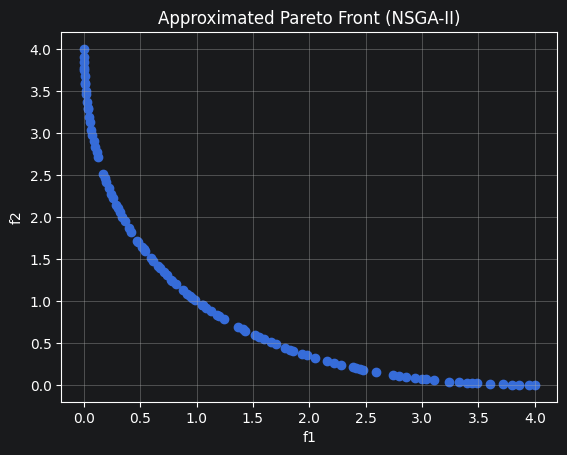

In [38]:
import matplotlib.pyplot as plt

plt.scatter(res.F[:, 0], res.F[:, 1])
plt.xlabel("f1")
plt.ylabel("f2")
plt.title("Approximated Pareto Front (NSGA-II)")
plt.grid()
plt.show()

In [35]:
from pymoo.problems import get_problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
import matplotlib.pyplot as plt

# problem
problem = get_problem("tnk")

# algorithm
algorithm = NSGA2(pop_size=100)

# optimization
res = minimize(
    problem,
    algorithm,
    termination=("n_gen", 100),
    seed=1,
    verbose=True
)

# -------------------
# results
# -------------------
print("Decision variables (X):")
print(res.X)

print("\nObjective values (F):")
print(res.F)

n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      igd      |       gd      |       hv     
     1 |      100 |      1 |  0.000000E+00 |  6.9626081652 |  0.4334523082 |  0.0696937788 |  0.0861364192
     2 |      200 |      7 |  0.000000E+00 |  1.4452084117 |  0.2327841093 |  0.1492538418 |  0.1005182961
     3 |      300 |      9 |  0.000000E+00 |  0.2000368085 |  0.0731603258 |  0.0661383752 |  0.2032353430
     4 |      400 |     11 |  0.000000E+00 |  0.0049004344 |  0.0579561523 |  0.0423350407 |  0.2390941652
     5 |      500 |     10 |  0.000000E+00 |  0.000000E+00 |  0.0543811610 |  0.0321355590 |  0.2521648295
     6 |      600 |     13 |  0.000000E+00 |  0.000000E+00 |  0.0477927710 |  0.0273075731 |  0.2601834261
     7 |      700 |     17 |  0.000000E+00 |  0.000000E+00 |  0.0458931853 |  0.0283609141 |  0.2643422042
     8 |      800 |     18 |  0.000000E+00 |  0.000000E+00 |  0.0456764441 |  0.0261636319 |  0.2704805599
     9 |      900 |     20 |  0.00000

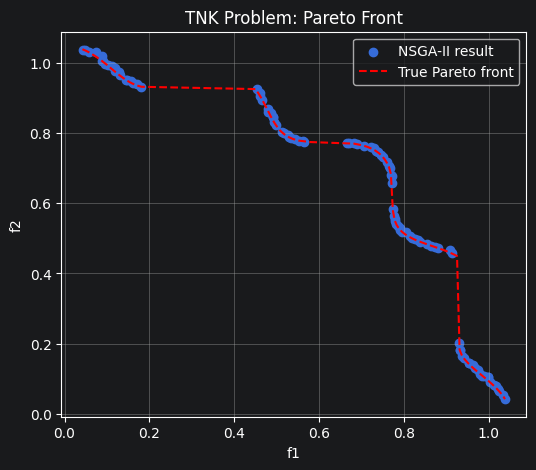

In [34]:
plt.figure(figsize=(6, 5))

# NSGA-II result (approximation)
plt.scatter(res.F[:, 0], res.F[:, 1], label="NSGA-II result")

# true Pareto front
pf = problem.pareto_front()
plt.plot(pf[:, 0], pf[:, 1], 'r--', label="True Pareto front")

plt.xlabel("f1")
plt.ylabel("f2")
plt.title("TNK Problem: Pareto Front")
plt.legend()
plt.grid()
plt.show()

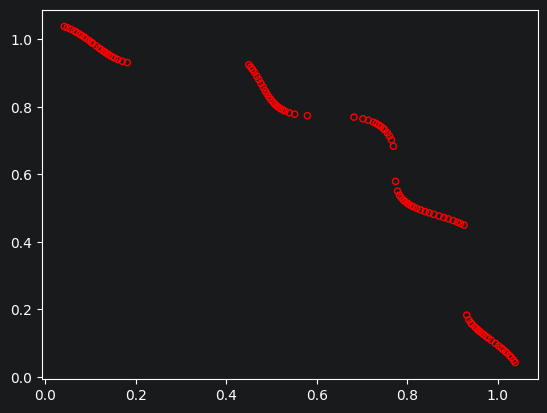

In [28]:
from pymoo.problems import get_problem
from pymoo.visualization.util import plot

problem = get_problem("tnk")
plot(problem.pareto_front(), no_fill=True)

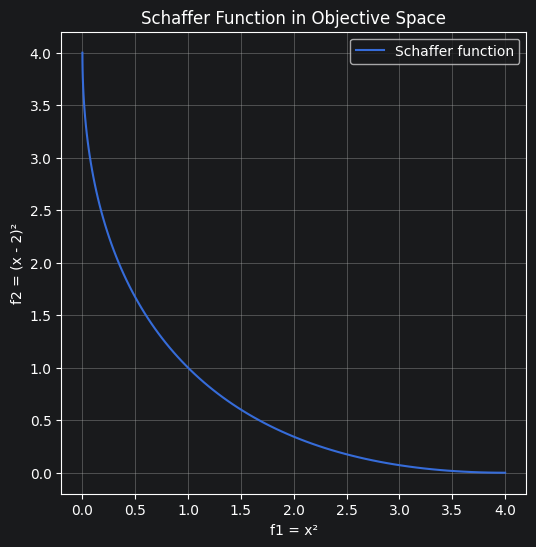

In [31]:
plt.figure(figsize=(6, 6))
plt.plot(f1, f2, label="Schaffer function")
plt.xlabel("f1 = x²")
plt.ylabel("f2 = (x - 2)²")
plt.title("Schaffer Function in Objective Space")
plt.grid()
plt.legend()
plt.show()

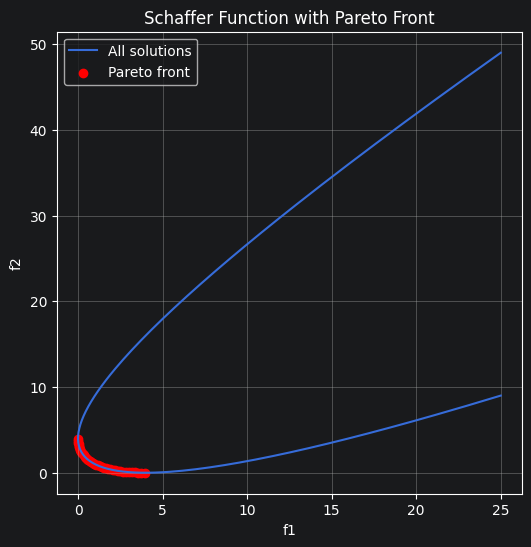

In [13]:
pareto_mask = (x >= 0) & (x <= 2)

plt.figure(figsize=(6, 6))

plt.plot(f1, f2, label="All solutions")
plt.scatter(f1[pareto_mask], f2[pareto_mask], color="red", label="Pareto front")

plt.xlabel("f1")
plt.ylabel("f2")
plt.title("Schaffer Function with Pareto Front")
plt.grid()
plt.legend()
plt.show()